<a href="https://colab.research.google.com/github/vnlsupraja/CrimeLensAI/blob/master/Netflix_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Netflix Data Analysis for Business Decision Making**


##1. Problem Statement

Netflix wants to understand the characteristics of the content available on its platform so that it can decide:

*   Which type of content (Movies or TV Shows) should be produced more.
*   Which countries should be targeted for future expansion.
*   Which countries should be targeted for future expansion.
*   Which genres, directors and actors are most popular.
*   When is the best time to release or add new content.

The objective of this analysis is to generate business insights and recommendations using Exploratory Data Analysis (EDA).

##2. Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

##3. Load Dataset

In [2]:
#Loading the dataset
from google.colab import files # Import the files module for Google Colab
uploaded = files.upload()

Saving netflix.csv to netflix.csv


In [3]:
#Reading the dataset
df = pd.read_csv("netflix.csv") # Read the CSV file into a pandas DataFrame

In [4]:
# Display the first 5 rows of the DataFrame
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


##4. Basic metrics

In [5]:
#Indentify the shape of the dataset
df.shape # Returns a tuple representing the dimensionality of the DataFrame

(8807, 12)

######Observation:The dataset contains 8,807 titles with 12 features describing Movies and TV Shows available on Netflix.

In [6]:
df.columns # Returns the column labels of the DataFrame

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.dtypes # Returns a Series with the data type of each column

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [8]:
df.info() # Prints a concise summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


######Observation:
1.   Most columns are object datatype.
2.   Release Year is numerical.
3.   Date Added should be converted into datetime.






In [9]:
df.describe() # Generates descriptive statistics of the DataFrame

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
df.describe(include='object') # Generates descriptive statistics for object (categorical) columns

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


######Observation:


1.   Release years range from old classics to recent content.
2.   There are numerous unique titles, directors, and countries, indicating a diverse catalog.



##5. Convert Datatypes

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed') # Convert the 'date_added' column to datetime by inferring mixed formats
df['type'] = df['type'].astype('category') # Convert the 'type' column to a categorical data type
df['rating'] = df['rating'].astype('category') # Convert the 'rating' column to a categorical data type

In [12]:
df['year'] = df['date_added'].dt.year # Extract the year from 'date_added' and create a new 'year' column
df['month'] = df['date_added'].dt.month_name() # Extract the month name from 'date_added' and create a new 'month' column

In [13]:
df.info() # Confirms the data types of the DataFrame after conversion, and checks for non-null counts.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   category      
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year          8797 non-null   float64       
 13  month         8797 non-null   object        
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 843.8+ 

##6. Missing Value Analysis

In [14]:
df.isnull().sum() # Calculates and displays the total number of missing values for each column

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


######Observation:


1.   Director has the highest number of missing values.
2.   Country and Cast also contain missing values.
3. Date has very few missing values.



##7. Duplicate Records

In [15]:
df.duplicated().sum() # Counts the total number of duplicate rows in the DataFrame

np.int64(0)

######Observation: No duplicate records present.

##8. Data Preprocessing


#####Columns such as Country, Director, Cast and Listed_in contain multiple values separated by commas.

In [16]:
# Process the 'country' column to handle multiple countries and clean up entries
country_df=df.assign(country=df['country'].str.split(',')).explode('country')

country_df['country']=country_df['country'].str.strip()

In [47]:
country_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


In [17]:
# Process the 'director' column to handle multiple directors and clean up entries
director_df=df.assign(director=df['director'].str.split(',')).explode('director')

director_df['director']=director_df['director'].str.strip()

In [46]:
director_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


In [18]:
# Process the 'cast' column to handle multiple cast members and clean up entries
cast_df=df.assign(cast=df['cast'].str.split(',')).explode('cast')

cast_df['cast']=cast_df['cast'].str.strip()

In [45]:
cast_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,Thabang Molaba,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September


In [19]:
# Process the 'listed_in' (genre) column to handle multiple genres and clean up entries
genre_df=df.assign(listed_in=df['listed_in'].str.split(',')).explode('listed_in')

genre_df['listed_in']=genre_df['listed_in'].str.strip()

In [20]:
genre_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,September


##9. Non Graphical Analysis

In [21]:
# Calculate the number of unique values in each column
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1714
release_year,74
rating,17
duration,220


In [22]:
# Analyze the distribution of content types of Netflix
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


######Observation: Movies constitute the majority of Netflix's content.

In [23]:
# Analyze the distribution of content ratings and find the top rating
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


######Observation: TV-MA and TV-14 are the most common maturity ratings.

In [24]:
# Analyze the top 10 countries with the most content on Netflix
country_df['country'].value_counts().head(10)

,count
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


######Observation: The United States contributes the highest number of titles.

In [25]:
# Analyze the top 10 genres with the most content on Netflix
genre_df['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


######Observation: International Movies, Drama,and Comedy dominate Netflix's library.

##10. Duration Cleaning

In [26]:
# Filter movies and convert their duration to a numerical format.
movies=df[df['type']=="Movie"].copy()

movies['duration']=movies['duration'].str.replace(" min","")

movies['duration']=movies['duration'].astype(float)

In [27]:
# Filter TV shows and convert their duration (number of seasons) to a numerical format.
shows=df[df['type']=='TV Show'].copy()

shows['duration']=shows['duration'].str.replace(' Seasons','')
shows['duration']=shows['duration'].str.replace(' Season','')

shows['duration']=shows['duration'].astype(float)

##11. Visual Analysis

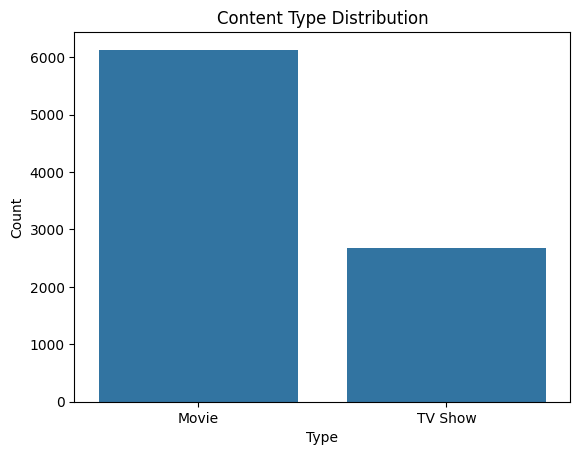

In [28]:
# Visualize the distribution of content types (Movie vs. TV Show).
sns.countplot(x='type',data=df)

plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

######Observation: Movies account for nearly 70% of Netflix's content, indicating a stronger focus on films.

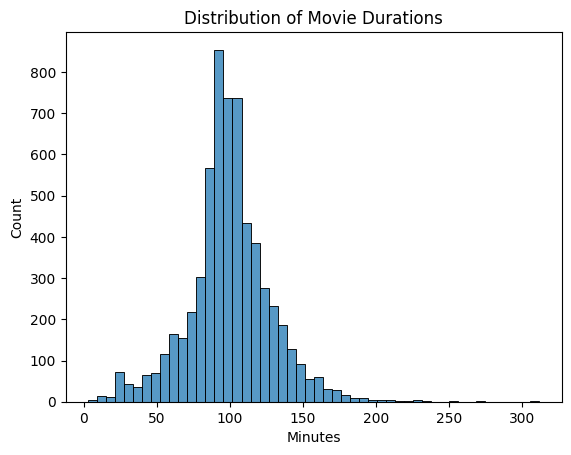

In [29]:
# Visualize the distribution of movie durations.
sns.histplot(movies['duration'],bins=50)

plt.xlabel("Minutes")
plt.ylabel("Count")
plt.title("Distribution of Movie Durations")
plt.show()

######Observation: Most movies are between 80 and 120 minutes, suggesting Netflix favors standard-length films.


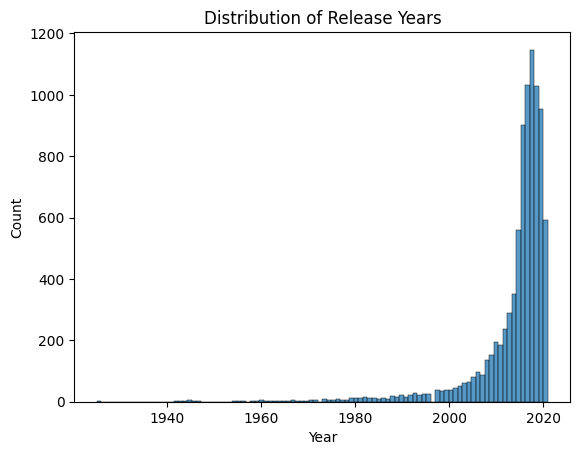

In [30]:
# Visualize the distribution of release years using a histogram.
sns.histplot(df['release_year'],bins=100)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Distribution of Release Years")

plt.show()

Observation: The plot reveals a significant increase in content released over time, with the majority of titles added in recent years (mid-2010s to 2020). This suggests Netflix primarily focuses on modern entertainment.

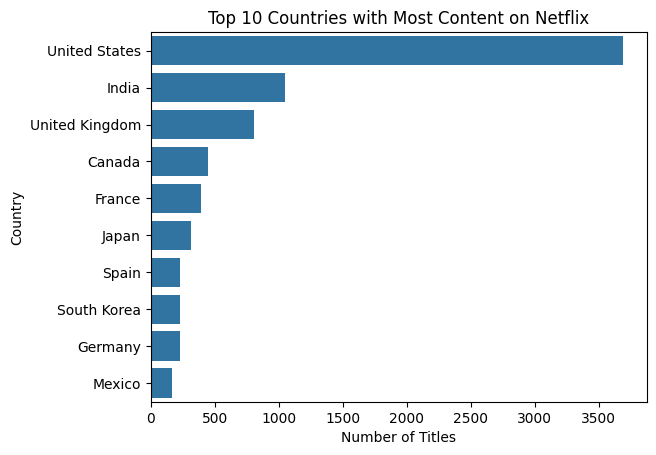

In [31]:
# Visualize the top 10 countries with the most content on Netflix.
top=country_df['country'].value_counts().head(10)

sns.barplot(x=top.values,y=top.index)
plt.title('Top 10 Countries with Most Content on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

Observation: The United States leads by a significant margin, followed by India and the United Kingdom.

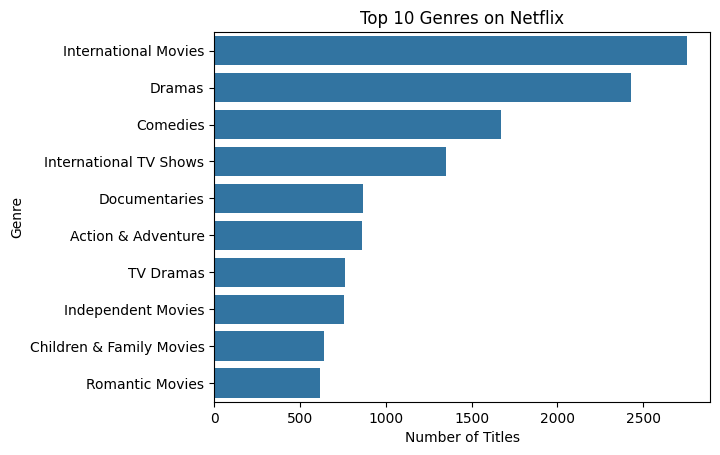

In [32]:
# Visualize the top 10 genres with the most content on Netflix.
top=genre_df['listed_in'].value_counts().head(10)

sns.barplot(x=top.values,y=top.index)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

Observation: The plot clearly shows that 'International Movies' and 'Dramas' are the most prevalent genres on Netflix, followed closely by 'Comedies'. This indicates a strong focus on these categories, suggesting they are key pillars of Netflix's content strategy.

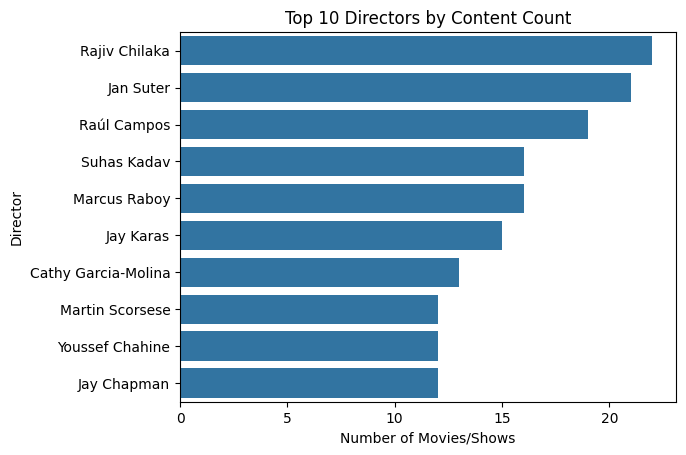

In [33]:
# Visualize the top 10 directors with the most content on Netflix.
top=director_df['director'].value_counts().head(10)

sns.barplot(x=top.values,y=top.index)
plt.title('Top 10 Directors by Content Count')
plt.xlabel('Number of Movies/Shows')
plt.ylabel('Director')
plt.show()

Observation: The plot highlights that Rajiv Chilaka is the most prolific director on Netflix, followed closely by Jan Suter and Raúl Campos. This suggests a strong emphasis on content from a relatively small group of high-volume directors who consistently contribute to the platform's library.

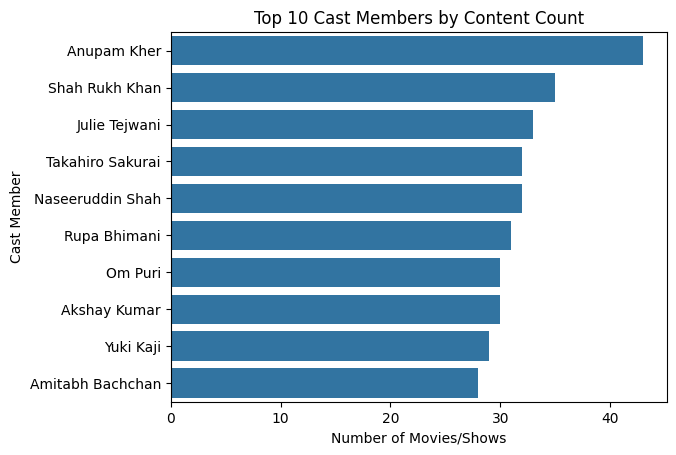

In [34]:
# Visualize the top 10 cast members with the most content on Netflix.
top=cast_df['cast'].value_counts().head(10)

sns.barplot(x=top.values,y=top.index)
plt.title('Top 10 Cast Members by Content Count')
plt.xlabel('Number of Movies/Shows')
plt.ylabel('Cast Member')
plt.show()

Observation: The visualization reveals that Anupam Kher is the most prolific cast member, followed by Shah Rukh Khan, with a notable dominance of actors from the Indian film industry among the top contributors.

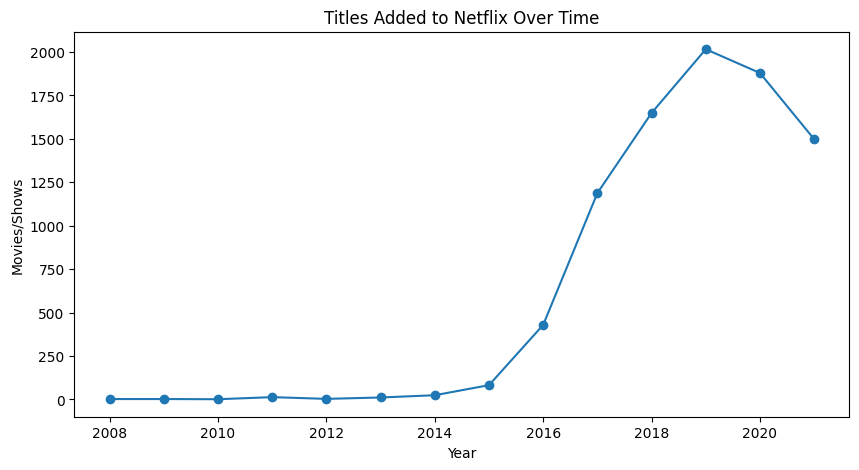

In [37]:
# Visualize the number of titles added to Netflix over the years.
year=df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year.index,year.values,marker='o')
plt.title('Titles Added to Netflix Over Time')
plt.xlabel("Year")
plt.ylabel("Movies/Shows")
plt.show()

Observation: The visualization clearly illustrates a significant increase in content added to Netflix over time, with a sharp rise observed from 2015 onwards, peaking around 2019. This trend reflects Netflix's aggressive content expansion strategy during that period, indicating a strong focus on continuously growing its library.

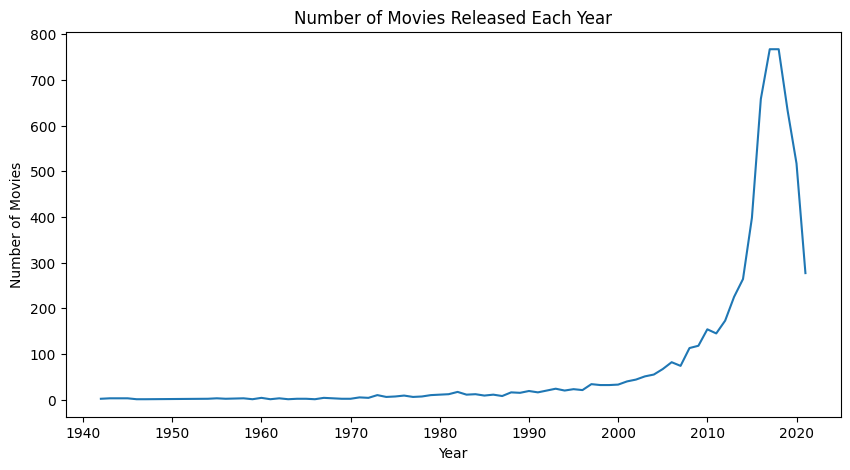

In [40]:
# Visualize the number of movies released each year.
movie_year=df[df['type']=='Movie']['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(movie_year.index,movie_year.values)
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

Observation: The plot illustrates a significant surge in movie releases starting in the early 2000s, reaching a peak around 2017-2018. This indicates a period of accelerated content production within the film industry, reflecting increased investment and output. Subsequently, there is a discernible decline in the number of new movies released, suggesting a potential shift in production trends or a saturation point in recent years.

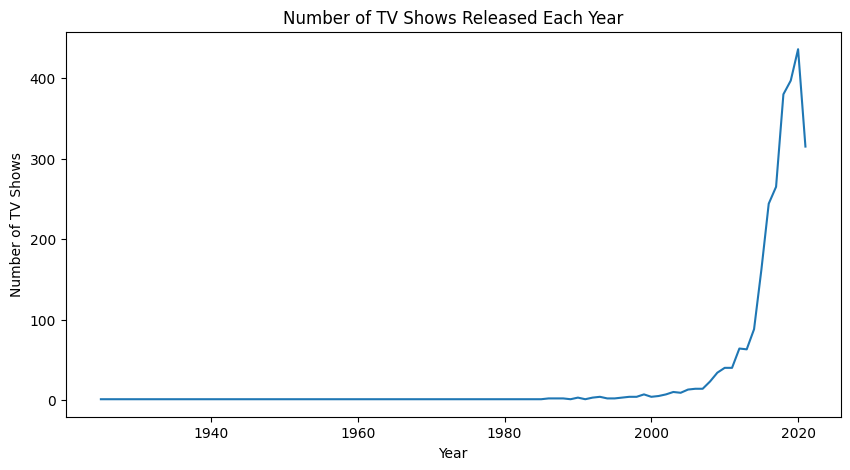

In [41]:
# Visualize the number of TV shows released each year.
tv_year=df[df['type']=="TV Show"]['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(tv_year.index,tv_year.values)
plt.title('Number of TV Shows Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of TV Shows')
plt.show()

Observations: The plot demonstrates a substantial rise in TV show releases, particularly after 2010, with a steep acceleration from 2015 to 2020. This trend highlights Netflix's increasing investment in episodic content, reflecting a strategic shift towards TV shows in recent years

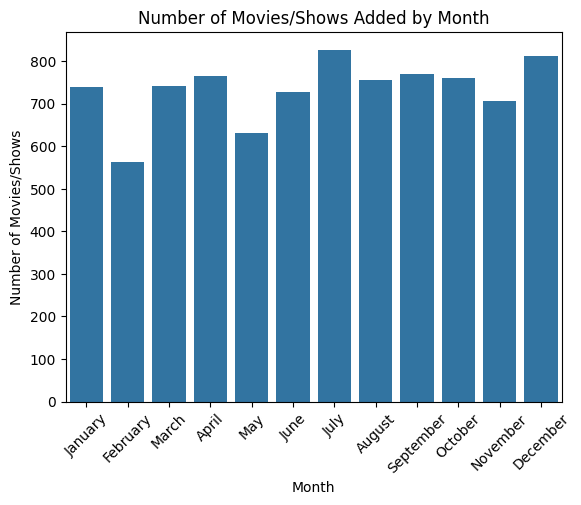

In [44]:
# Visualize the number of titles added to Netflix by month.
order=['January','February','March','April','May','June',
       'July','August','September','October','November','December']

sns.countplot(x='month',
              data=df,
              order=order)

plt.title('Number of Movies/Shows Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Movies/Shows')
plt.xticks(rotation=45)
plt.show()

Observation: The plot shows a noticeable variation in content additions throughout the year, with July and December standing out as months with significantly higher numbers of new movies and shows. Conversely, February and May appear to have comparatively fewer additions. This pattern suggests a strategic release schedule, potentially aligning with holiday seasons or periods of increased viewer engagement.

##12. Outlier Analysis

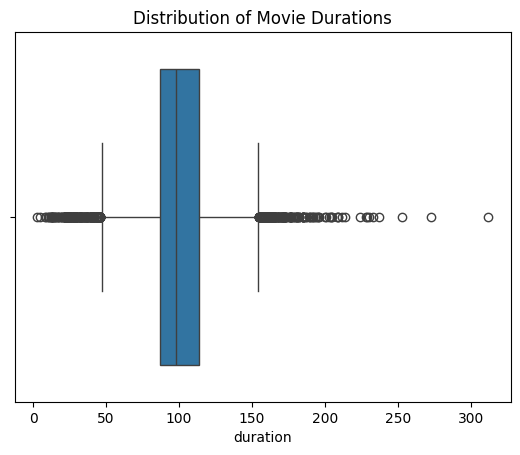

In [38]:
# Visualize the distribution of movie durations using a box plot.
sns.boxplot(x=movies['duration'])
plt.title('Distribution of Movie Durations')
plt.show()

Observation: This plot confirms the earlier observation from the histogram that most movies on Netflix have a standard length, typically falling within the 80-120 minute range, with a few exceptionally long or short films.

##13. Overall Insights

1. Movies dominate Netflix's content library, making up the majority of available titles.

2. TV Shows have experienced strong growth in recent years, indicating increasing investment in episodic content.

3. The United States contributes the highest number of titles, followed by India, highlighting these as key production markets.

4. Drama, Comedy, and International Movies are the most common genres, reflecting audience demand for diverse storytelling.

5. Most movies have a runtime between 80 and 120 minutes, which appears to be the preferred format.

6. Netflix significantly expanded its content additions between 2016 and 2019, suggesting an aggressive content acquisition strategy.

7. TV-MA and TV-14 ratings dominate the catalog, showing that Netflix primarily targets mature and teenage audiences.

8. Certain directors and actors appear frequently, suggesting long-term collaborations with successful creators.

##14. Business Recomendations

1. Continue investing in TV Shows, as their popularity and production have increased significantly in recent years.

2. Produce more regional content in high-performing markets such as India and the United States to attract local audiences.

3. Focus on Drama, Comedy, and International content since these genres dominate the platform.

4. Expand collaborations with frequently appearing directors and actors who have proven audience appeal.

5. Schedule major content releases during periods when Netflix historically adds more titles to maximize visibility.

6. Increase investments in emerging countries where Netflix has relatively low content availability to expand its global subscriber base.

7. Maintain a balanced portfolio of Movies and TV Shows to satisfy diverse viewer preferences.

8. Continue producing standard-length movies (80–120 minutes), as they align with the majority of successful titles.